/tmp/ipykernel_407780/3173172146.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Model', y='C2ST Score', data=df_plot,


Plot saved as c2st_comparison_fixed.png


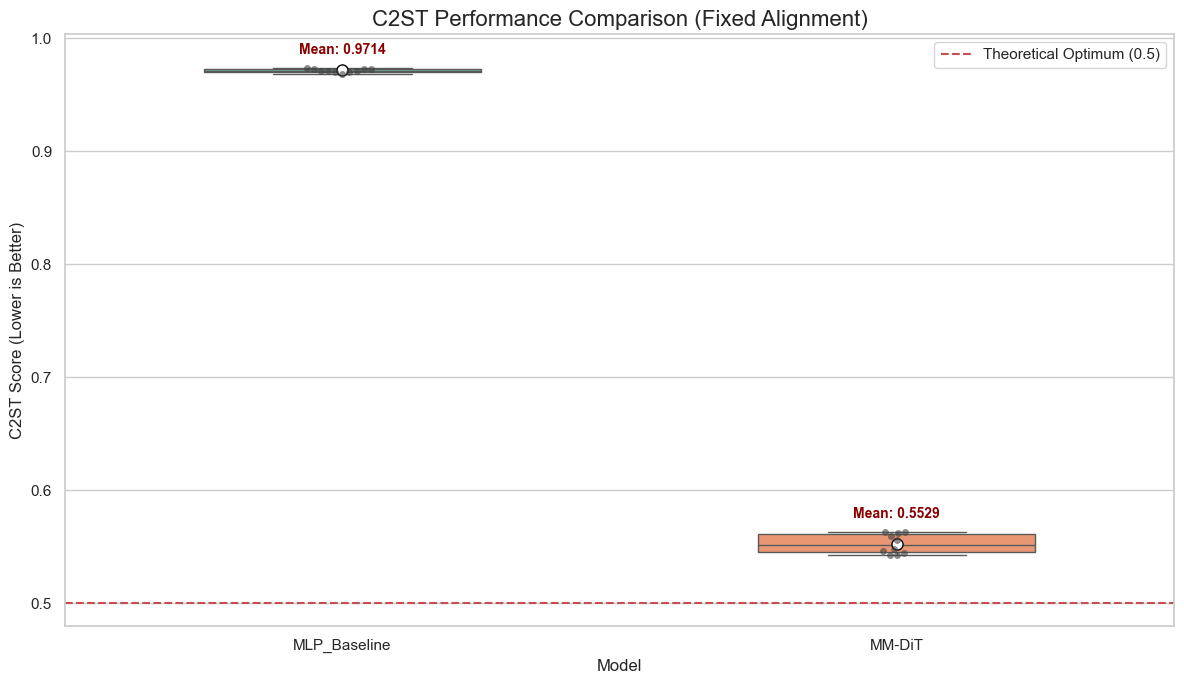

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_c2st_comparison(file_dict):
    """
    Reads C2ST results and creates a comparison box plot with fixed label ordering.
    均值标注显示在每个箱图的最上方，无箭头标识
    """
    all_data = []
    # 保持字典中定义的顺序
    model_order = list(file_dict.keys())

    for label, path in file_dict.items():
        if not os.path.exists(path):
            print(f"Warning: File {path} not found.")
            continue
            
        df = pd.read_csv(path)
        # 确保只取第一行数值（防止文件中有重复行）
        values = df.iloc[0].values.astype(float)
        
        temp_df = pd.DataFrame({
            'Model': [label] * len(values),
            'C2ST Score': values
        })
        all_data.append(temp_df)

    if not all_data:
        return

    df_plot = pd.concat(all_data, ignore_index=True)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # 绘制箱图并获取绘图后的轴对象
    ax = sns.boxplot(x='Model', y='C2ST Score', data=df_plot, 
                     order=model_order,
                     palette="Set2", width=0.5, showmeans=True,
                     meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
    
    # 绘制散点图
    sns.swarmplot(x='Model', y='C2ST Score', data=df_plot, 
                  order=model_order,
                  color=".25", alpha=0.6, ax=ax)

    # 绘制理论最优值横线
    plt.axhline(y=0.5, color='r', linestyle='--', label='Theoretical Optimum (0.5)')

    # 计算每个模型的最大值和均值，标注在箱图最上方（无箭头）
    for i, model in enumerate(model_order):
        # 提取该模型的所有C2ST分数
        model_data = df_plot[df_plot['Model'] == model]['C2ST Score']
        m_val = model_data.mean()  # 均值
        max_val = model_data.max()  # 该模型的最大值（箱图顶部）
        
        # 在箱图最大值上方标注均值，移除箭头参数
        ax.annotate(f'Mean: {m_val:.4f}', 
                    xy=(i, max_val),  # 定位到箱图最大值位置
                    xytext=(0, 8),    # 向上偏移8个点，避免与箱图重叠
                    textcoords='offset points',
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color='darkred')  # 删除arrowprops参数

    # 设置标题、标签和Y轴范围
    plt.title('C2ST Performance Comparison (Fixed Alignment)', fontsize=16)
    plt.ylabel('C2ST Score (Lower is Better)', fontsize=12)
    # 调整Y轴上限，给顶部标注留出空间
    y_max = df_plot['C2ST Score'].max()
    plt.ylim(0.48, y_max + 0.03)  # 微调上限偏移，适配无箭头的标注
    plt.legend()
    plt.tight_layout()
    
    plt.savefig('c2st_comparison_fixed.png', dpi=300, bbox_inches='tight')  # 防止标注被裁剪
    print("Plot saved as c2st_comparison_fixed.png")
    plt.show()

if __name__ == "__main__":
    # 这里的顺序将决定图中从左到右的顺序
    results_to_plot = {
        'MLP_Baseline': '/home/vrlab/GW/flowmatching_record/gaussian_linear_MLP/c2st.csv',
        # 'MMDiT_128_8': '/home/vrlab/GW/flow_matching/flow-matching-posterior-estimation/train_t_128_deep8/c2st.csv',
        # 'MMDiT_128_4': '/home/vrlab/GW/flow_matching/flow-matching-posterior-estimation/train_t_128_deep4/c2st.csv',
        # 'MMDiT_256_8': '/home/vrlab/GW/flow_matching/flow-matching-posterior-estimation/train_t_256_deep8/c2st.csv',
        # 'MMDiT_256_4': '/home/vrlab/GW/flow_matching/flow-matching-posterior-estimation/train_t_256_deep4/c2st.csv',
        # 'MMDiT_64_8': '/home/vrlab/GW/flow_matching/flow-matching-posterior-estimation/train_t_64_deep8/c2st.csv',
        'MM-DiT': '/home/vrlab/GW/flowmatching_record/gaussian_linear_MM-DiT/c2st.csv',
    }
    
    plot_c2st_comparison(results_to_plot)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class C2ST_Evaluator:
    def __init__(self, input_dim, device="cuda", hidden_dim=64, learning_rate=1e-3, batch_size=64, epochs=10):
        """
        初始化 C2ST 评估器
        """
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.lr = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs

    def _build_model(self):
        """构建一个简单的二分类器 (MLP)"""
        model = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim), # 多加一层增加拟合能力
            nn.ReLU(),
            nn.Linear(self.hidden_dim, 1),
            # 注意：这里不加 Sigmoid，直接输出 Logits，配合 BCEWithLogitsLoss 使用更稳定
        ).to(self.device)
        return model

    def compute_c2st(self, P, Q, test_size=0.3):
        """
        计算 C2ST 指标
        :param P: 分布 P 的样本 (N, D) Tensor
        :param Q: 分布 Q 的样本 (M, D) Tensor (通常 N=M)
        :param test_size: 测试集比例
        :return: Accuracy (float)
        """
        # 1. 确保数据在设备上
        P = P.to(self.device)
        Q = Q.to(self.device)
        
        N, M = P.shape[0], Q.shape[0]
        
        # 2. 构建标签 (P=0, Q=1)
        # 使用 BCEWithLogitsLoss，标签需要是 float 类型
        labels_P = torch.zeros(N, 1, device=self.device)
        labels_Q = torch.ones(M, 1, device=self.device)
        
        X = torch.cat([P, Q], dim=0)
        y = torch.cat([labels_P, labels_Q], dim=0)
        
        # 3. 手动划分训练/测试集 (全在 GPU 上进行)
        total_samples = X.shape[0]
        indices = torch.randperm(total_samples, device=self.device)
        split_idx = int(total_samples * (1 - test_size))
        
        train_idx, test_idx = indices[:split_idx], indices[split_idx:]
        
        # 创建 DataLoader (如果数据量极大，这步可以分批；如果显存够，可以直接切片)
        # 这里为了通用性使用 Mini-batch
        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        test_dataset = TensorDataset(X[test_idx], y[test_idx])
        
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        # 测试集 batch 可以大一点
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size * 4, shuffle=False)
        
        # 4. 初始化模型和优化器
        model = self._build_model()
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        criterion = nn.BCEWithLogitsLoss()
        
        # 5. 训练循环
        model.train()
        for _ in range(self.epochs):
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                logits = model(x_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()
        
        # 6. 测试循环 (计算 Accuracy)
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                logits = model(x_batch)
                preds = (torch.sigmoid(logits) > 0.5).float()
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)
        
        return correct / total

# ================= 使用示例 =================

if __name__ == "__main__":
    # 模拟数据
    dim = 20
    n_samples = 100000
    
    # 确保生成就在 GPU 上 (如果显存允许)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 情况 A: 分布完全不同 (Mean 0 vs Mean 1) -> C2ST 应该接近 1.0
    dist_p = torch.randn(n_samples, dim, device=device)
    dist_q = torch.randn(n_samples, dim, device=device) + 1.0
    
    evaluator = C2ST_Evaluator(input_dim=dim, device=device, epochs=20)
    score_diff = evaluator.compute_c2st(dist_p, dist_q)
    
    print(f"当前设备: {device}")
    print(f"不同分布 C2ST Score (期望 ~1.0): {score_diff:.4f}")

    # 情况 B: 分布相同 -> C2ST 应该接近 0.5
    dist_p2 = torch.randn(n_samples, dim, device=device)
    dist_q2 = torch.randn(n_samples, dim, device=device) # 同分布
    
    score_same = evaluator.compute_c2st(dist_p2, dist_q2)
    print(f"相同分布 C2ST Score (期望 ~0.5): {score_same:.4f}")

当前设备: cuda
不同分布 C2ST Score (期望 ~1.0): 0.9860
相同分布 C2ST Score (期望 ~0.5): 0.4978
